We will use Mixscape to maximize the signal by perturbation using the "perturbation signature", then further classify cells within each perturbation as "perturbed" or "non-perturbed" (i.e., demonstrating an expression shift in PC space or clustering with control cells). 

In [91]:
import os

import scanpy as sc
import numpy as np

import sys
sclembas_path = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas_path))
from scLEMBAS import io
from scLEMBAS import preprocess as pp


[KeOps] Warning : There were warnings or errors :
<stdin>:1:10: fatal error: cuda.h: No such file or directory
compilation terminated.

[KeOps] Warning : 
    The location of Cuda header files cuda.h and nvrtc.h could not be detected on your system.
    You must determine their location and then define the environment variable CUDA_PATH,
    either before launching Python or using os.environ before importing keops. For example
    if these files are in /vol/cuda/10.2.89-cudnn7.6.4.38/include you can do :
      import os
      os.environ['CUDA_PATH'] = '/vol/cuda/10.2.89-cudnn7.6.4.38'
    
[KeOps] Compiling cuda jit compiler engine ... 
[KeOps] Warning : There were warnings or errors :
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/nvrtc_jit.cpp:16:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK
[pyKeOps] Compiling nvrtc binder for python ... 
[KeOps] W

In [2]:
n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

In [3]:
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
author = 'Tahoe100M'
seed = 888

In [37]:
adata = sc.read_h5ad(os.path.join(data_path, 'interim', author + '_normalized_counts.h5ad'))

In [39]:
n_frac = 0.05
rng = np.random.default_rng(seed=42)
adata = adata[rng.choice(adata.n_obs,
                         size=int(n_frac * adata.n_obs),
                         replace=False), :]
adata

View of AnnData object with n_obs × n_vars = 36732 × 16227
    obs: 'sample', 'gene_count', 'tscp_count', 'mread_count', 'drugname_drugconc', 'drug', 'cell_line', 'sublibrary', 'BARCODE', 'pcnt_mito', 'S_score', 'G2M_score', 'phase', 'pass_filter', 'cell_name', 'plate', 'condition', 'drug_target', 'drug_moa'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

Calculate perturbation score:

In [83]:
ms = Mixscape()
adata_pert = ms.perturbation_signature(
    adata = adata, 
    pert_key = 'drug',
    control = 'DMSO_TF', 
    ref_selection_mode = 'nn', # use nearest control neighbors
    split_by = 'plate', # do within replicates
    n_neighbors = 20, # default recommendation from Mixscape
    use_rep = 'X_pca', # calculated on PC space determines from log1p HVGs, as in original Mixscape
    n_dims = adata.uns['pca']['pca_rank'], 
    batch_size = None, # compute in batches for memory, 
    copy = True, 
    **{
        'random_state': seed, 
        'n_jobs': n_cores, 
        'verbose': True
    }
)
adata_pert.X = adata_pert.layers["X_pert"]
del adata_pert.layers['X_pert']

  0%|                                                     | 0/6 [00:00<?, ?it/s]

Thu Sep  4 15:42:33 2025 Building RP forest with 9 trees
Thu Sep  4 15:42:34 2025 NN descent for 8 iterations
	 1  /  8
	 2  /  8
	 3  /  8
	Stopping threshold met -- exiting after 3 iterations
Thu Sep  4 15:42:34 2025 Worst tree score: 0.97570850
Thu Sep  4 15:42:34 2025 Mean tree score: 0.98965362
Thu Sep  4 15:42:34 2025 Best tree score: 1.00000000
Thu Sep  4 15:42:34 2025 Forward diversification reduced edges from 7410 to 1201
Thu Sep  4 15:42:34 2025 Reverse diversification reduced edges from 1201 to 1201
Thu Sep  4 15:42:34 2025 Degree pruning reduced edges from 1218 to 1218
Thu Sep  4 15:42:34 2025 Resorting data and graph based on tree order
Thu Sep  4 15:42:34 2025 Building and compiling search function


 17%|███████▌                                     | 1/6 [01:26<07:11, 86.22s/it]

Thu Sep  4 15:43:59 2025 Building RP forest with 9 trees
Thu Sep  4 15:43:59 2025 NN descent for 8 iterations
	 1  /  8
	 2  /  8
	Stopping threshold met -- exiting after 2 iterations
Thu Sep  4 15:43:59 2025 Worst tree score: 0.97422680
Thu Sep  4 15:43:59 2025 Mean tree score: 0.98969072
Thu Sep  4 15:43:59 2025 Best tree score: 1.00000000
Thu Sep  4 15:43:59 2025 Forward diversification reduced edges from 5820 to 964
Thu Sep  4 15:43:59 2025 Reverse diversification reduced edges from 964 to 964
Thu Sep  4 15:43:59 2025 Degree pruning reduced edges from 992 to 992
Thu Sep  4 15:43:59 2025 Resorting data and graph based on tree order
Thu Sep  4 15:43:59 2025 Building and compiling search function


 33%|███████████████                              | 2/6 [01:55<03:31, 52.85s/it]

...

 67%|██████████████████████████████               | 4/6 [03:37<01:43, 51.88s/it]

Thu Sep  4 15:46:10 2025 Building RP forest with 9 trees
Thu Sep  4 15:46:10 2025 NN descent for 7 iterations
	 1  /  7
	 2  /  7
	Stopping threshold met -- exiting after 2 iterations
Thu Sep  4 15:46:10 2025 Worst tree score: 0.98802395
Thu Sep  4 15:46:10 2025 Mean tree score: 0.99467731
Thu Sep  4 15:46:10 2025 Best tree score: 1.00000000
Thu Sep  4 15:46:10 2025 Forward diversification reduced edges from 5010 to 816
Thu Sep  4 15:46:10 2025 Reverse diversification reduced edges from 816 to 816
Thu Sep  4 15:46:10 2025 Degree pruning reduced edges from 820 to 820
Thu Sep  4 15:46:10 2025 Resorting data and graph based on tree order
Thu Sep  4 15:46:10 2025 Building and compiling search function


 83%|█████████████████████████████████████▌       | 5/6 [03:54<00:39, 39.29s/it]

Thu Sep  4 15:46:27 2025 Building RP forest with 8 trees
Thu Sep  4 15:46:27 2025 NN descent for 7 iterations
	 1  /  7
	 2  /  7
	Stopping threshold met -- exiting after 2 iterations
Thu Sep  4 15:46:27 2025 Worst tree score: 0.98290598
Thu Sep  4 15:46:27 2025 Mean tree score: 0.99252137
Thu Sep  4 15:46:27 2025 Best tree score: 1.00000000
Thu Sep  4 15:46:27 2025 Forward diversification reduced edges from 3510 to 553
Thu Sep  4 15:46:27 2025 Reverse diversification reduced edges from 553 to 553
Thu Sep  4 15:46:27 2025 Degree pruning reduced edges from 558 to 558
Thu Sep  4 15:46:27 2025 Resorting data and graph based on tree order
Thu Sep  4 15:46:27 2025 Building and compiling search function


100%|█████████████████████████████████████████████| 6/6 [04:14<00:00, 42.36s/it]


Get the dimensionality reduction on the perturbation signature:

Note a discrepancy here: pertpy scales AND zero-centers the DE-subsetted perturbation signature (in the mixscape method), whereas the original Mixscape only zero-centers the entire matrix without subsetting. We will proceed with the pertpy implementation for simplicity. We run PCA on the HVGs identified from the expression matrix as in the Mixscape paper. 

Identify the rank

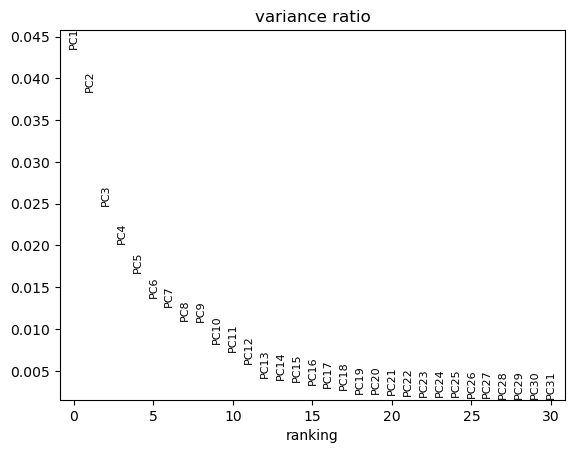

The elbow was automatically identified at PC 13


In [92]:
sc.pp.pca(
    adata_pert, 
    zero_center = True,
    random_state = seed, 
    mask_var = 'highly_variable', # use hvgs identified on log1p data
)

n_pcs = pp._compute_elbow(adata, curve='convex', direction='decreasing')
adata.uns["pca"]['pca_rank'] = n_pcs

sc.pl.pca_variance_ratio(adata)
print('The elbow was automatically identified at PC {}'.format(n_pcs))

In [ ]:
r2_df_linear = pp.latent_association(
    adata = adata_pert,
    covariates = ['cell_line', 'drug', 'plate', 'phase', 'S_score', 'G2M_score', 'pcnt_mito'], 
    model_type = 'linear', 
    latent_label = 'pca',
    n_cores = n_cores, 
    seed = seed
)

r2_df_nl = pp.latent_association(
    adata = adata_pert,
    covariates = ['cell_line', 'drug', 'plate', 'phase', 'S_score', 'G2M_score', 'pcnt_mito'], 
    model_type = 'nonlinear', 
    latent_label = 'pca',
    n_cores = n_cores, 
    seed = seed
)

r2_df = pd.concat([r2_df_linear, r2_df_nl])
r2_df.to_csv(os.path.join(data_path, 'processed', author + '_mspertsig_pc_associations.csv'))

r2_df = pd.read_csv(os.path.join(data_path, 'processed', author + '_mspertsig_pc_associations.csv'), 
                   index_col = 0)

cell_line


100%|███████████████████████████████████████████| 50/50 [00:00<00:00, 94.98it/s]


drug


100%|███████████████████████████████████████████| 50/50 [00:02<00:00, 23.14it/s]


plate


...

100%|██████████████████████████████████████████| 50/50 [00:00<00:00, 427.55it/s]


cell_line


100%|███████████████████████████████████████████| 50/50 [00:16<00:00,  2.94it/s]


drug


 68%|█████████████████████████████▏             | 34/50 [00:32<00:15,  1.06it/s]

In [95]:
adata_pert

AnnData object with n_obs × n_vars = 36732 × 16227
    obs: 'sample', 'gene_count', 'tscp_count', 'mread_count', 'drugname_drugconc', 'drug', 'cell_line', 'sublibrary', 'BARCODE', 'pcnt_mito', 'S_score', 'G2M_score', 'phase', 'pass_filter', 'cell_name', 'plate', 'condition', 'drug_target', 'drug_moa'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

# you are here

In [78]:
"""Lightweight version of pertpy's Mixscape implementation (v1.0.2) to be used without needing to install the full package."""

from typing import Literal

from tqdm import tqdm

from anndata import AnnData
from scanpy.tools._utils import _choose_representation
from scipy.sparse import csr_matrix, issparse, spmatrix


def center_adata(adata):
    """Centers AnnData object without scaling"""

    if issparse(adata.X):
        # Calculate mean and broadcast properly for sparse subtraction
        mean_vals = np.array(adata.X.mean(axis=0)).flatten()
        # Create a sparse matrix with the same shape where each row is the mean
        mean_matrix = csr_matrix(np.tile(mean_vals, (adata.X.shape[0], 1)))
        adata.X = adata.X - mean_matrix
    else:
        adata.X = adata.X - adata.X.mean(axis=0)

class Mixscape:
    """identify perturbation effects in CRISPR screens by separating cells into perturbation groups."""

    def __init__(self):
        pass

    def perturbation_signature(
        self,
        adata: AnnData,
        pert_key: str,
        control: str,
        *,
        ref_selection_mode: Literal["nn", "split_by"] = "nn",
        split_by: str | None = None,
        n_neighbors: int = 20,
        use_rep: str | None = None,
        n_dims: int | None = 15,
        n_pcs: int | None = None,
        batch_size: int | None = None,
        copy: bool = False,
        **kwargs,
    ):
        """
        Compute a per-cell perturbation signature relative to control cells.

        The signature is the difference between each cell’s mRNA expression profile and
        the average profile of matched control cells (selected via `ref_selection_mode`).
        This follows the idea in Seurat Mixscape. Note that the original implementation
        computes signatures on **unscaled** data; we recommend doing the same.

        Parameters
        ----------
        adata : AnnData
            Annotated data matrix.
        pert_key : str
            Column in :attr:`adata.obs` with perturbation categories. Must include `control`.
        control : str
            Name of the control category present in :paramref:`pert_key`.
        ref_selection_mode : {'nn', 'split_by'}, default 'nn'
            Strategy to select control reference cells.
            - ``'nn'``: For each perturbed cell, use the ``n_neighbors`` most similar
            control cells (in the chosen representation). *Note, selecting 'nn' does not negate the 
            ``'split_by'`` argument; will still choose the neargest-neighbors, but within the biological replicate
            - ``'split_by'``: Use all control cells from the same group defined by
            :paramref:`split_by` (e.g., biological replicate).
        split_by : str or None, default None
            Column in :attr:`adata.obs` indicating splits (e.g., replicate) used when
            ``ref_selection_mode='split_by'``.
        n_neighbors : int, default 20
            Number of nearest control neighbors to use when ``ref_selection_mode='nn'``.
        use_rep : str or None, default None
            Representation to use. Accepts ``'X'`` or a key in :attr:`adata.obsm`.
            If ``None``: use :attr:`adata.X` when ``adata.n_vars < 50``, else try
            ``'X_pca'`` (computed with default parameters if absent).
        n_dims : int or None, default 15
            Number of leading dimensions from the chosen representation to use. If
            ``None``, use all available dimensions.
        n_pcs : int or None, default None
            Number of principal components to compute when a PCA representation is used.
            If ``n_pcs == 0`` and ``use_rep is None``, fall back to :attr:`adata.X`.
        batch_size : int or None, default None
            Batch size used to compute signatures. If ``None``, computes in a single
            pass (higher memory). Batched mode can be inefficient for sparse data.
        copy : bool, default False
            If ``True``, return a copy of ``adata`` with signatures written to
            ``.layers['X_pert']``. Otherwise, modify ``adata`` in place and return ``None``.
        **kwargs
            Additional keyword arguments forwarded to :class:`pynndescent.NNDescent`
            when ``ref_selection_mode='nn'``.

        Returns
        -------
        AnnData or None
            If ``copy=True``, a copy of ``adata`` with the perturbation signatures stored in
            ``adata.layers['X_pert']``. If ``copy=False``, modifies ``adata`` in place and
            returns ``None``.

        Notes
        -----
        Inspired by Seurat Mixscape:
        https://satijalab.org/seurat/reference/runmixscape

        Examples
        --------
        Calculate perturbation signatures per cell:

        >>> import pertpy as pt
        >>> mdata = pt.dt.papalexi_2021()
        >>> ms = pt.tl.Mixscape()
        >>> ms.perturbation_signature(mdata["rna"], "perturbation", "NT", split_by="replicate")
        """
        ...

        if ref_selection_mode not in ["nn", "split_by"]:
            raise ValueError("ref_selection_mode must be either 'nn' or 'split_by'.")
        if ref_selection_mode == "split_by" and split_by is None:
            raise ValueError("split_by must be provided if ref_selection_mode is 'split_by'.")

        if copy:
            adata = adata.copy()

        adata.layers["X_pert"] = adata.X.copy()

        # Work with LIL for efficient indexing but don't store it in AnnData as LIL is not supported anymore
        X_pert_lil = adata.layers["X_pert"].tolil() if issparse(adata.layers["X_pert"]) else adata.layers["X_pert"]

        control_mask = adata.obs[pert_key] == control

        if ref_selection_mode == "split_by":
            for split in adata.obs[split_by].unique():
                split_mask = adata.obs[split_by] == split
                control_mask_group = control_mask & split_mask
                control_mean_expr = mean(adata.X[control_mask_group], axis=0)
                X_pert_lil[split_mask] = (
                    np.repeat(control_mean_expr.reshape(1, -1), split_mask.sum(), axis=0) - X_pert_lil[split_mask]
                )
        else:
            if split_by is None:
                split_masks = [np.full(adata.n_obs, True, dtype=bool)]
            else:
                split_obs = adata.obs[split_by]
                split_masks = [split_obs == cat for cat in split_obs.unique()]

            representation = _choose_representation(adata, use_rep=use_rep, n_pcs=n_pcs)
            if n_dims is not None and n_dims < representation.shape[1]:
                representation = representation[:, :n_dims]

            from pynndescent import NNDescent

            for split_mask in tqdm(split_masks):
                control_mask_split = control_mask & split_mask
                R_split = representation[split_mask]
                R_control = representation[np.asarray(control_mask_split)]
                eps = kwargs.pop("epsilon", 0.1)
                nn_index = NNDescent(R_control, **kwargs)
                indices, _ = nn_index.query(R_split, k=n_neighbors, epsilon=eps)
                X_control = np.expm1(adata.X[np.asarray(control_mask_split)])
                n_split = split_mask.sum()
                n_control = X_control.shape[0]

                if batch_size is None:
                    col_indices = np.ravel(indices)
                    row_indices = np.repeat(np.arange(n_split), n_neighbors)
                    neigh_matrix = csr_matrix(
                        (np.ones_like(col_indices, dtype=np.float64), (row_indices, col_indices)),
                        shape=(n_split, n_control),
                    )
                    neigh_matrix /= n_neighbors
                    X_pert_lil[np.asarray(split_mask)] = (
                        sc.pp.log1p(neigh_matrix @ X_control) - X_pert_lil[np.asarray(split_mask)]
                    )
                else:
                    split_indices = np.where(split_mask)[0]
                    for i in range(0, n_split, batch_size):
                        size = min(i + batch_size, n_split)
                        select = slice(i, size)
                        batch = np.ravel(indices[select])
                        split_batch = split_indices[select]
                        size = size - i
                        means_batch = X_control[batch]
                        batch_reshaped = means_batch.reshape(size, n_neighbors, -1)
                        means_batch, _ = mean_var(batch_reshaped, axis=1)
                        X_pert_lil[split_batch] = np.log1p(means_batch) - X_pert_lil[split_batch]

        if issparse(X_pert_lil):
            adata.layers["X_pert"] = X_pert_lil.tocsr()
        else:
            adata.layers["X_pert"] = X_pert_lil

        if copy:
            return adata
